In [32]:
import numpy as np
from mpi4py import MPI
from basix.ufl import element
from dolfinx import mesh, fem, io, plot
from ufl import TrialFunction, TestFunction, dx

from pylab import meshgrid
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pyvista
import ufl
from pathlib import Path
from dolfinx.fem.petsc import LinearProblem
from petsc4py import PETSc

from dolfinx import *

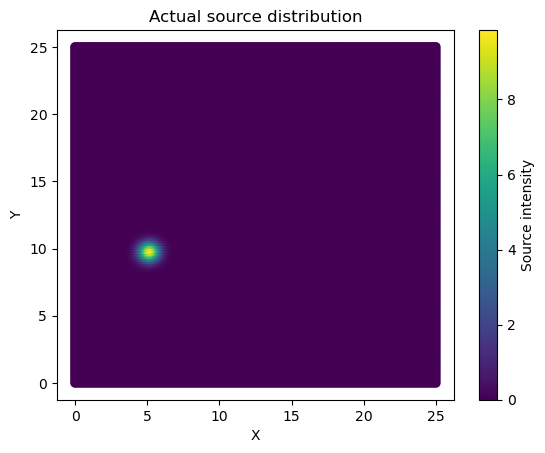

In [33]:
# Create mesh and define function space
y_lim = 25.0
x_lim = 25.0

domain = mesh.create_rectangle(MPI.COMM_WORLD, ((0,0),(x_lim, y_lim)), [128, 128])
V = fem.functionspace(domain, element("CG", domain.basix_cell(), 1))

# Parameters
D_phys = fem.Constant(domain, 0.1)
theta = fem.Constant(domain, 0.5)
t_end = 40
dt = 0.4

# Velocity field
def velocity_field(x):
    return np.vstack((0.5 * np.ones_like(x[0]), 0.5 * np.ones_like(x[0])))

V_vec = fem.functionspace(domain, ("CG", 1, (domain.geometry.dim,)))
beta = fem.Function(V_vec)
beta.interpolate(velocity_field)

x0, y0 = 0.2 * x_lim, 0.4 * y_lim
sigma_x, sigma_y = 0.02 * x_lim, 0.02 * y_lim  # Standardabweichung

# Source term als 2D-Gauss
def source_term(x: np.ndarray):
    values = 10.0 * np.exp(-((x[0] - x0)**2 / (2 * sigma_x**2) + (x[1] - y0)**2 / (2 * sigma_y**2)))
    return values

f_true = fem.Function(V)
f_true.interpolate(source_term)

# Boundary condition (zero dirichlet)
def boundary(x):
    return np.isclose(x[0], 0.0) | np.isclose(x[1], 0.0)
    
u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V, boundary), V)

x_coords = domain.geometry.x[:, 0]
y_coords = domain.geometry.x[:, 1]
f_values = f_true.x.array

plt.figure()
plt.scatter(x_coords, y_coords, c=f_values, cmap='viridis')
plt.colorbar(label='Source intensity')
plt.title('Actual source distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

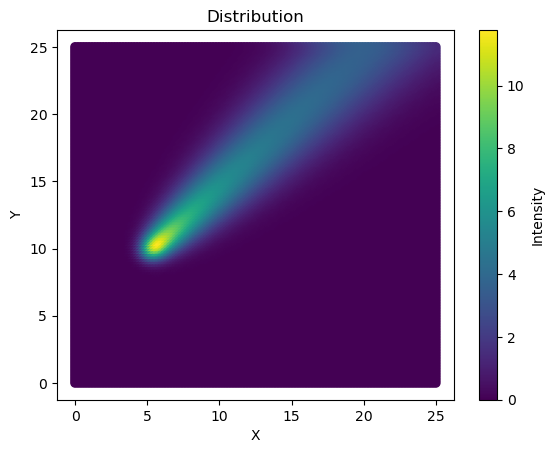

In [34]:
U_char = ufl.sqrt(ufl.dot(beta, beta))
L_char = fem.Constant(domain, x_lim)
h = ufl.CellDiameter(domain)
Pe = U_char * L_char / D_phys
nb = ufl.sqrt(ufl.inner(beta, beta))

tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * nb, -1.0)

v = TestFunction(V)
u = TrialFunction(V)

# a = D_phys * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + ufl.inner(beta, ufl.grad(u)) * v * dx
# L = f_true * v * dx

# SUPG
a_stab = D_phys * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + ufl.inner(beta, ufl.grad(u)) * v * dx + \
         tau * ufl.inner(beta, ufl.grad(u)) * ufl.inner(beta, ufl.grad(v)) * dx
L_stab = f_true * v * dx + tau * f_true * ufl.inner(beta, ufl.grad(v)) * dx

forward_problem = LinearProblem(a_stab, L_stab, [bc_zero])
uh = forward_problem.solve()

plt.figure()
plt.scatter(x_coords, y_coords, c=uh.x.array, cmap='viridis')
plt.colorbar(label='Intensity')
plt.title('Distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
